<a href="https://colab.research.google.com/github/soulqan/PCVK_GANJIL_2025/blob/main/week7_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/soulqan/PCVK_GANJIL_2025/blob/main/week7_28.ipynb

# Praktikum Filter

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [16]:
img = cv.imread('/content/drive/MyDrive/images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
if img is None:
    print('Failed to load image file')
else:
    print('Success to load image file')

Success to load image file


In [17]:
def convolution2d(image, kernel, stride, padding):
  # Ukuran citra
  h, w = image.shape
  # Ukuran kernel
  kh, kw = kernel.shape

  # Tambahkan padding
  if padding > 0:
      padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
  else:
      padded = image

  # Hitung ukuran output
  oh = (h + 2 * padding - kh) // stride + 1
  ow = (w + 2 * padding - kw) // stride + 1

  # Buat citra output
  output = np.zeros((oh, ow), dtype=np.float32)

  # Proses konvolusi manual
  for i in range(0, oh):
          for j in range(0, ow):
              # ambil region sesuai kernel
              region = padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
              # kalikan dan jumlahkan
              value = np.sum(region * kernel)
              output[i, j] = value

  # Normalisasi agar nilai tetap 0..255
  output = np.clip(output, 0, 255).astype(np.uint8)

  return output

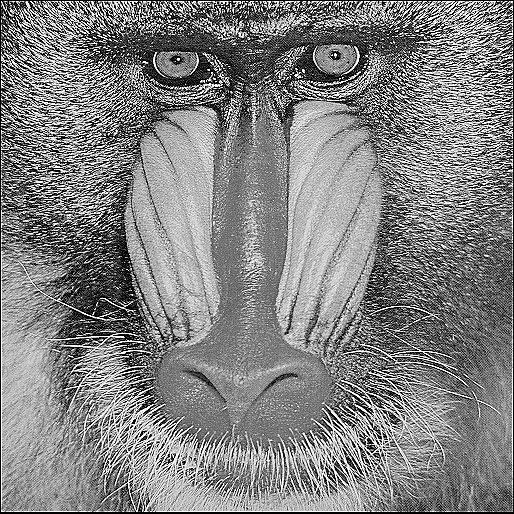

In [18]:
# Kernel Sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=float)

# Terapkan konvolusi
sharpened_image = convolution2d(img_gray, kernel_sharpen, 1,2)

# Tampilkan hasil
cv2_imshow(sharpened_image)

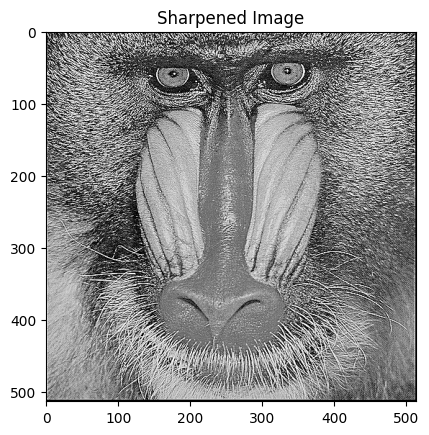

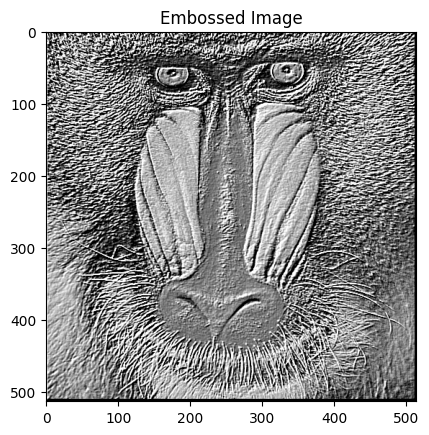

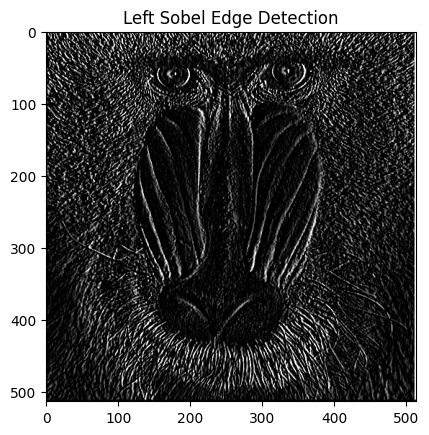

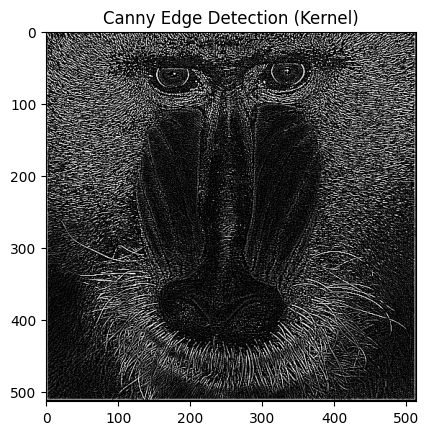

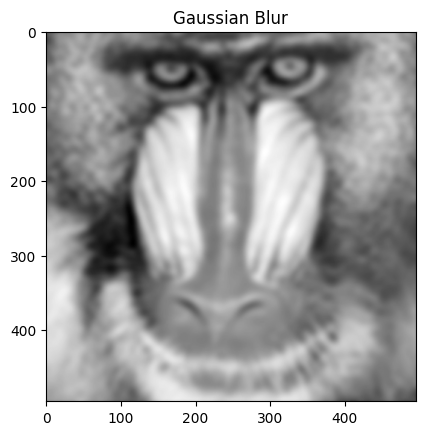

In [19]:
# Kernel sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=float)

kernel_emboss = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
], dtype=float)

kernel_leftSobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=float)

kernel_cannyEdge = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
], dtype=float)

# Kernel gaussian 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)
ax = np.linspace(-(kernel_size-1)/2., (kernel_size-1)/2., kernel_size)
xx, yy = np.meshgrid(ax, ax)
kernel_gaussian = np.exp(-0.5 * (xx**2 + yy**2) / (sigma**2))
kernel_gaussian = kernel_gaussian / np.sum(kernel_gaussian)


otp_sharpened = convolution2d(img_gray, kernel_sharpen, 1,2)
otp_emboss = convolution2d(img_gray, kernel_emboss, 1,2)
otp_leftSobel = convolution2d(img_gray, kernel_leftSobel, 1,2)
otp_cannyEdge = convolution2d(img_gray, kernel_cannyEdge, 1,2)
otp_gaussian = convolution2d(img_gray, kernel_gaussian, 1,2)

# Display results using matplotlib
images = [otp_sharpened, otp_emboss, otp_leftSobel, otp_cannyEdge, otp_gaussian]
titles = ['Sharpened Image', 'Embossed Image', 'Left Sobel Edge Detection', 'Canny Edge Detection (Kernel)', 'Gaussian Blur']

for i in range(len(images)):
    plt.figure()
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.show()

# Percobaan 1

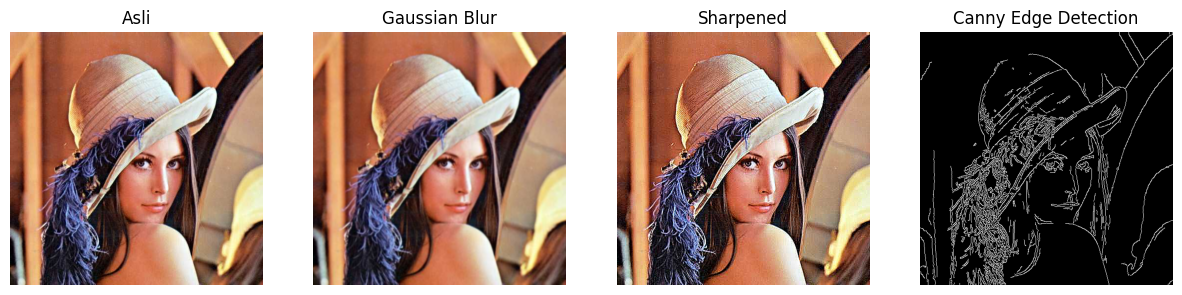

In [20]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        if len(images[i].shape) == 2: # grayscale
            plt.imshow(images[i], cmap="gray")
        else: # color
            # Matplotlib expects RGB, OpenCV reads BGR
            plt.imshow(cv.cvtColor(images[i], cv.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    # Removed plt.tight_layout() to avoid warning
    plt.show()

img = cv.imread("/content/drive/MyDrive/images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200) # Canny expects grayscale
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

# Percobaan 2

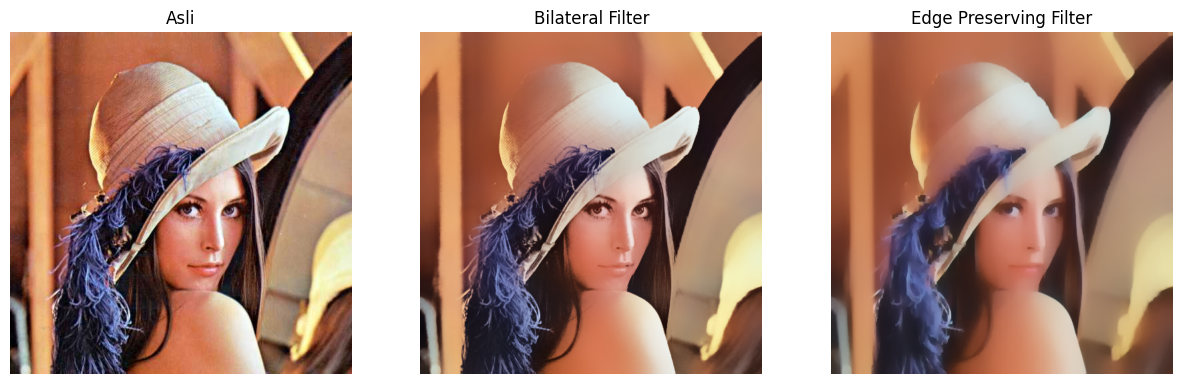

In [21]:
# filter modern dari opencv
# bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge preserving filter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

# Percobaan 3

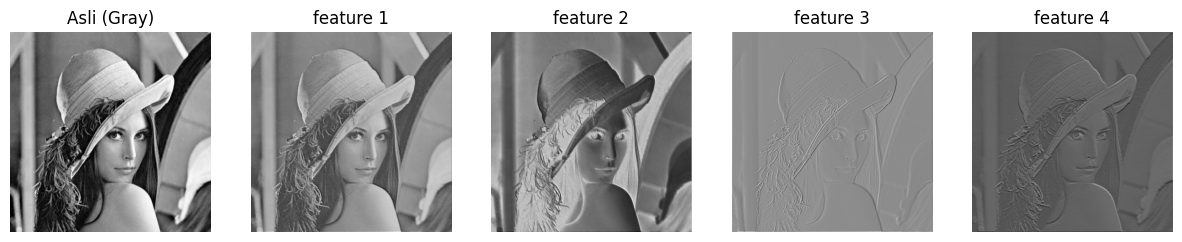

In [22]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Asli (Gray)'] + [f'feature {i+1}' for i in range(len(feature_maps))])

# Percobaan 4

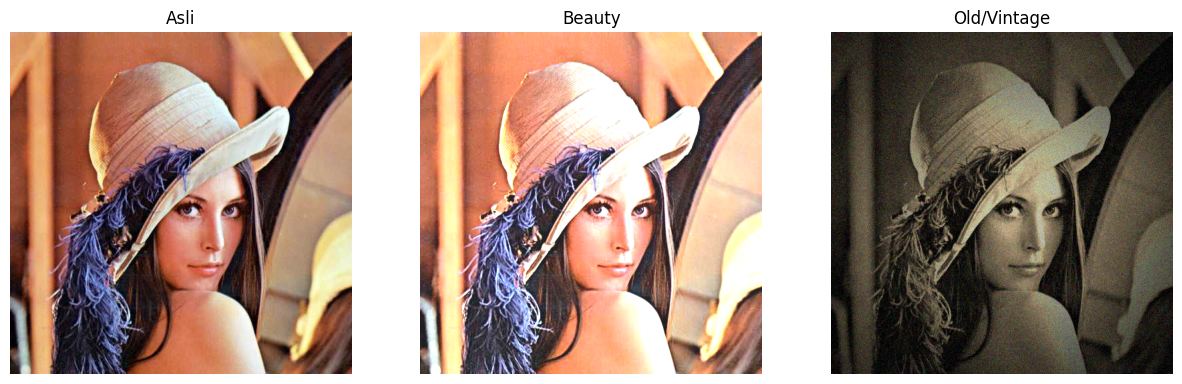

In [23]:
# ====================
# 1. Beauty Filter
# ====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(img, (0, 0), 3)
unsharp = cv.addWeighted(img, 1.5, gaussian, -0.5, 0)
sharpened = cv.addWeighted(unsharp, 0.8, smooth, 0.2, 0)

# Step 3: Brightness & contrast
beta = 30
alpha = 1.2
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ====================
# 2. Old/Vintage Filter
# ====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
old = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols,200)
kernel_y = cv.getGaussianKernel(rows,200)
kernel = kernel_y * kernel_x.T
mask = 255 * kernel / np.linalg.norm(kernel)
for i in range(3):
    old[:,:,i] = old[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 16, img.shape).astype(np.int16)
old_img = np.clip(old.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Tampilkan output side by side
show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty", "Old/Vintage"])

# Percobaan 5

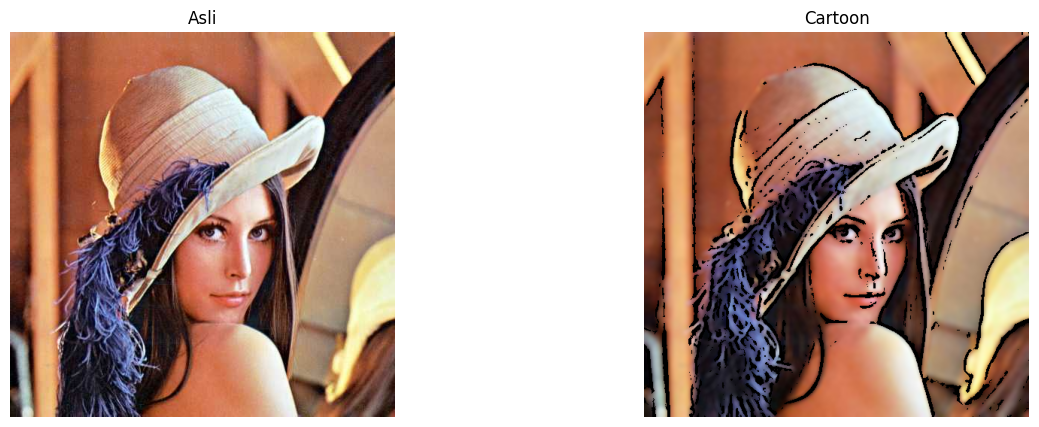

In [24]:
# Filter anime / Cartoon
# step 1: Edge detection (pakai median blur agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blurred = cv.medianBlur(gray, 5)
edges = cv.adaptiveThreshold(blurred, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, 9, 300, 300)

# step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# tampilkan
show_side_by_side([img, cartoon],
                  ["Asli", "Cartoon"])

# Percobaan 6

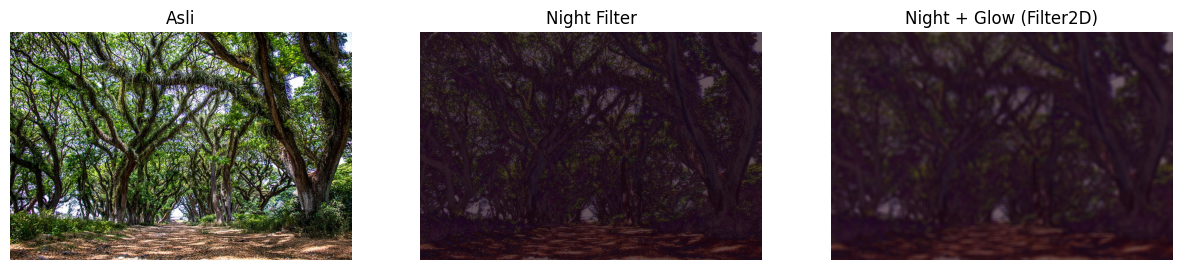

In [25]:
# Night filter
img = cv.imread('/content/drive/MyDrive/images/djwatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast, brightness, night effect)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru (Add blue bias)
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night_glow = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan blur (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night_glow, -1, kernel)

# Kombinasikan asli + glow (Combine original + glow)
night_glow = cv.addWeighted(night_glow, 0.6, glow, 0.3, 0)
show_side_by_side([img, night_glow, glow], ["Asli", "Night Filter", "Night + Glow (Filter2D)"])

# Percobaan 7

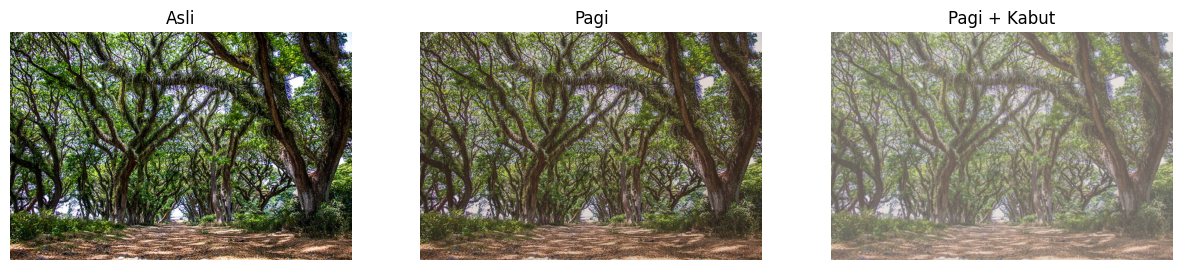

In [26]:
#Filter Suasana pagi dan Kabut

# Step 1: Kurangi kontras & cerahkan
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

#========================================
# Step 2: Tambahkan warna temoe (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

#========================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D

# membuat blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])